# EP1 - MLY1101 Machine Learning
## Caso C: Inteligencia musical y predicción de popularidad de canciones (Spotify Tracks)

Notebook con: comprensión del problema, EDA, y preparación de datos.

**Metodología:** CRISP-DM

## 1. Importación de librerías

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

## 2. Comprensión del problema de negocio

**Problema de negocio:** Predecir la popularidad de una canción (0-100) a partir de sus atributos de audio, para apoyar decisiones de marketing musical, curaduría de playlists y estrategia de lanzamiento de artistas.

**Objetivos del proyecto:**
- Identificar qué atributos de audio se relacionan con la popularidad.
- Preparar un dataset limpio y transformado apto para modelamiento.
- Evaluar sesgos y aspectos éticos del uso de estos datos.

**KPIs propuestos:**
- Correlación entre variables de audio y `popularity`.
- % de valores nulos/duplicados eliminados en la limpieza.
- Error de predicción (a definir en etapa de modelamiento, fuera del alcance de este EP1).

## 3. Carga de datos

In [5]:
df = pd.read_csv('../data/dataset.csv')
print(df.shape)
df.head()

(114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

## 4. Análisis Exploratorio de Datos (EDA)

### 4.1 Calidad de datos: nulos y duplicados

In [7]:
print('Valores nulos por columna:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\nFilas totalmente duplicadas:', df.duplicated().sum())
print('Duplicados por track_id:', df['track_id'].duplicated().sum())

Valores nulos por columna:
artists       1
album_name    1
track_name    1
dtype: int64

Filas totalmente duplicadas: 0
Duplicados por track_id: 24259


### 4.2 Estadísticas descriptivas

In [8]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [9]:
df.describe(include='object')

/tmp/ipykernel_82822/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,track_id,artists,album_name,track_name,track_genre
count,114000,113999,113999,113999,114000
unique,89741,31437,46589,73608,114
top,6S3JlDAGk3uu3NtZbPnuhS,The Beatles,Alternative Christmas 2022,Run Rudolph Run,acoustic
freq,9,279,195,151,1000


### 4.3 Distribución de la variable objetivo: popularity

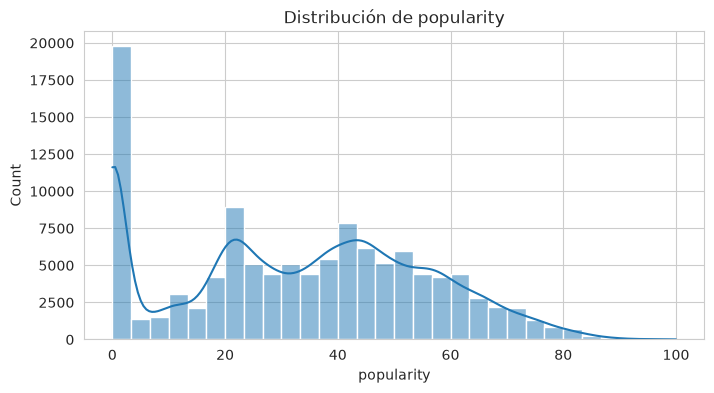

In [10]:
plt.figure(figsize=(8,4))
sns.histplot(df['popularity'], bins=30, kde=True)
plt.title('Distribución de popularity')
plt.savefig('../images/dist_popularity.png', bbox_inches='tight')
plt.show()

### 4.4 Distribución de variables numéricas de audio

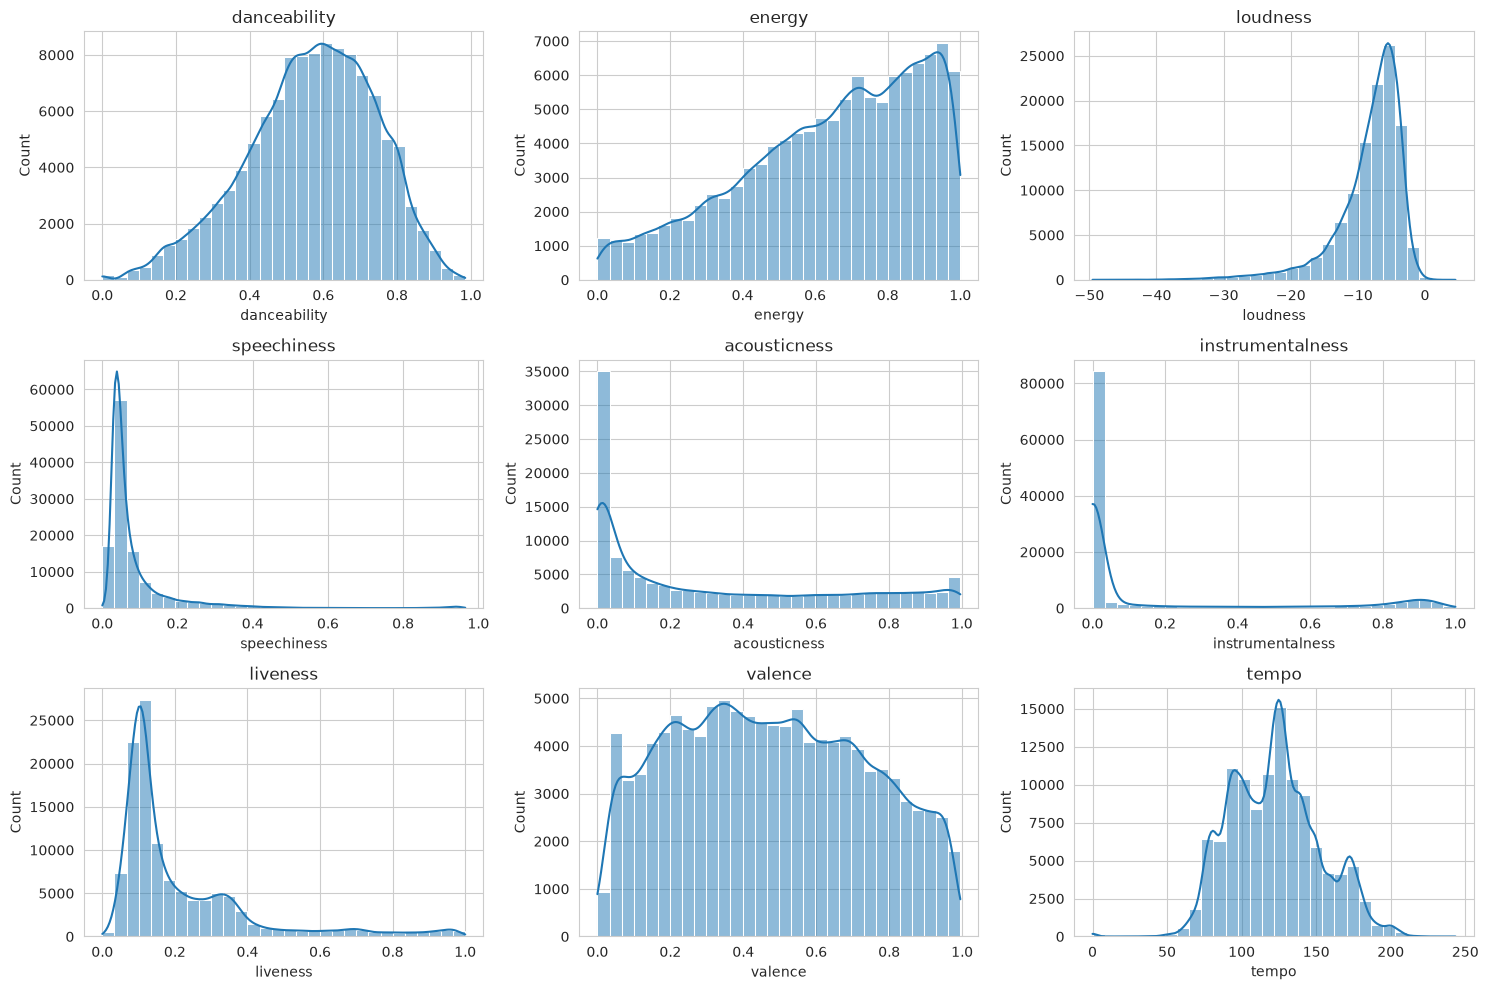

In [11]:
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), audio_features):
    sns.histplot(df[col], bins=30, ax=ax, kde=True)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../images/dist_audio_features.png', bbox_inches='tight')
plt.show()

### 4.5 Variables categóricas: género, explicit, key, mode

In [12]:
print('Número de géneros únicos:', df['track_genre'].nunique())
print(df['track_genre'].value_counts().head(10))

Número de géneros únicos: 114
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
anime          1000
black-metal    1000
bluegrass      1000
blues          1000
brazil         1000
Name: count, dtype: int64


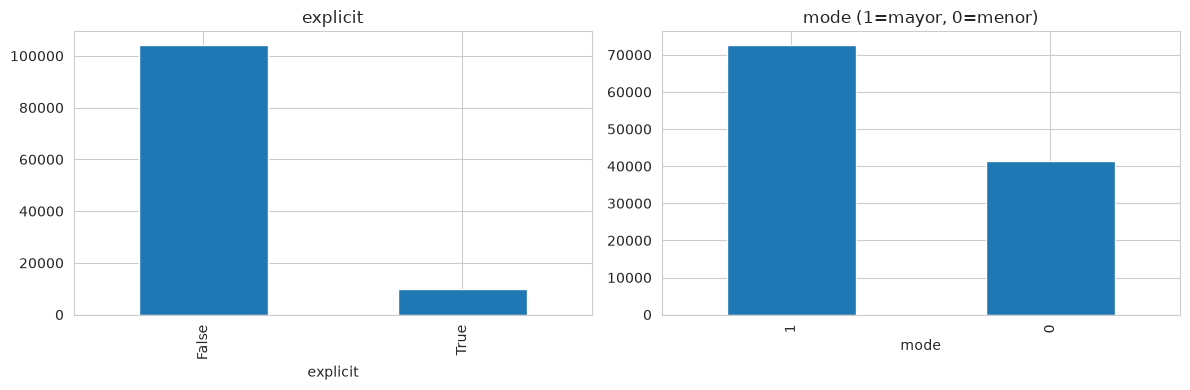

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df['explicit'].value_counts().plot(kind='bar', ax=axes[0], title='explicit')
df['mode'].value_counts().plot(kind='bar', ax=axes[1], title='mode (1=mayor, 0=menor)')
plt.tight_layout()
plt.show()

### 4.6 Detección de outliers

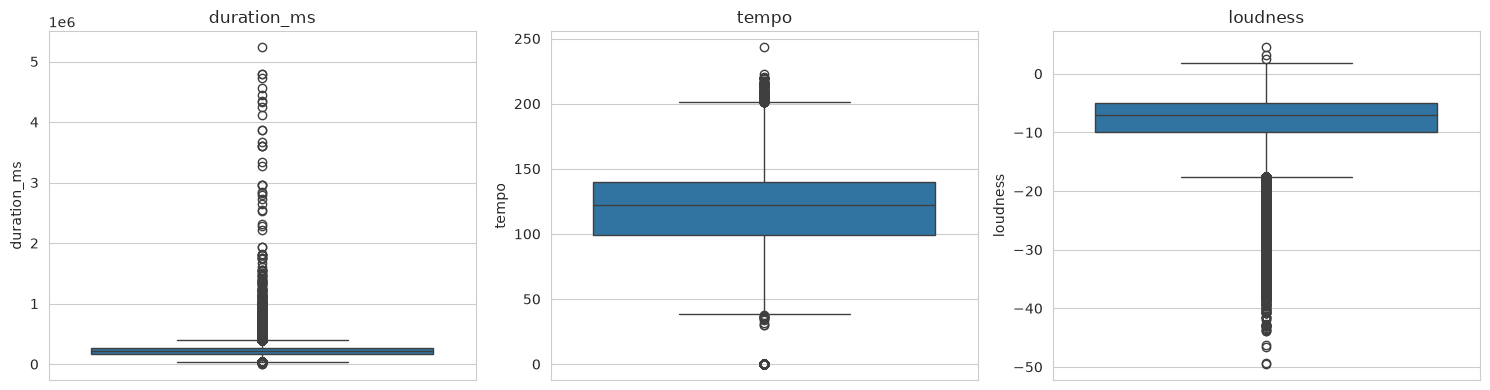

In [14]:
cols_outliers = ['duration_ms', 'tempo', 'loudness']
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, cols_outliers):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig('../images/outliers.png', bbox_inches='tight')
plt.show()

### 4.7 Correlaciones entre variables de audio y popularity

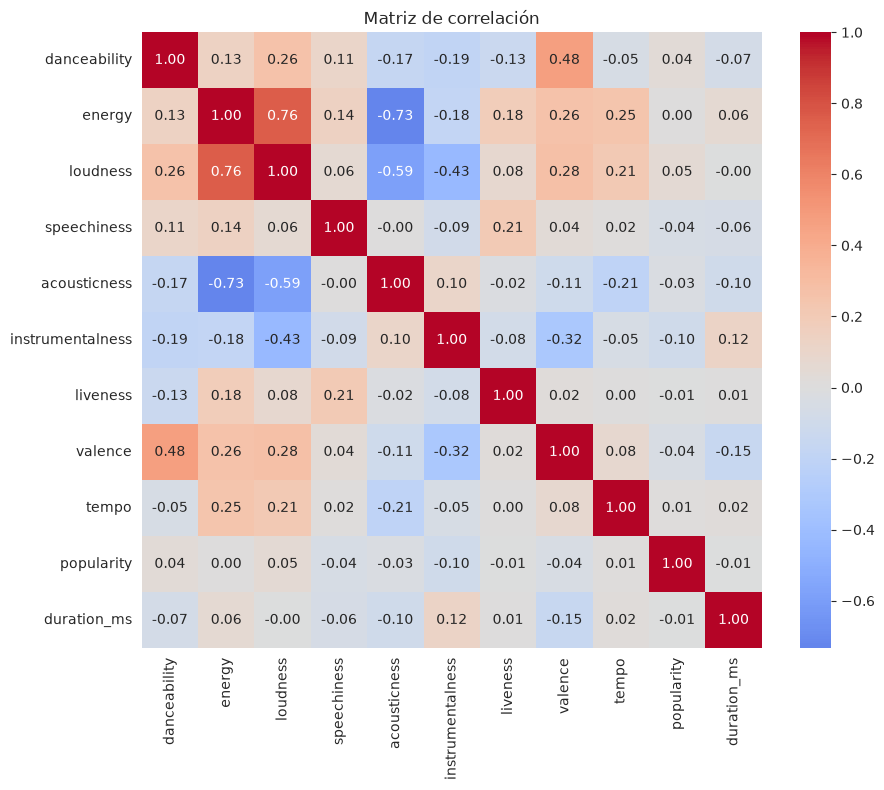

In [15]:
numeric_cols = audio_features + ['popularity', 'duration_ms']
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación')
plt.savefig('../images/correlacion.png', bbox_inches='tight')
plt.show()

## 5. Preparación y transformación de datos

### 5.1 Limpieza: nulos y duplicados

In [16]:
df_clean = df.copy()

# Eliminar filas con nulos (ajustar según lo que arroje el punto 4.1)
df_clean = df_clean.dropna()

# Eliminar duplicados exactos
df_clean = df_clean.drop_duplicates()

# Eliminar duplicados por track_id, conservando el de mayor popularidad
df_clean = df_clean.sort_values('popularity', ascending=False).drop_duplicates(subset='track_id', keep='first')

print('Shape original:', df.shape)
print('Shape limpio:', df_clean.shape)

Shape original: (114000, 21)
Shape limpio: (89740, 21)


### 5.2 Tratamiento de outliers (winsorización simple con percentiles)

In [17]:
def cap_outliers(series, lower=0.01, upper=0.99):
    q_low, q_high = series.quantile([lower, upper])
    return series.clip(q_low, q_high)

for col in ['duration_ms', 'tempo']:
    df_clean[col] = cap_outliers(df_clean[col])

### 5.3 Codificación de variables categóricas

In [18]:
df_clean['explicit'] = df_clean['explicit'].astype(int)

le_genre = LabelEncoder()
df_clean['track_genre_encoded'] = le_genre.fit_transform(df_clean['track_genre'])

df_clean[['track_genre', 'track_genre_encoded', 'explicit']].head()

,track_genre,track_genre_encoded,explicit
20001,dance,20,0
51664,hip-hop,51,0
88410,reggae,88,0
30003,edm,30,1
68304,latino,68,0


### 5.4 Escalado de variables numéricas

In [19]:
scaler = StandardScaler()
cols_to_scale = audio_features + ['duration_ms']

df_scaled = df_clean.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df_clean[cols_to_scale])

df_scaled[cols_to_scale].describe()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,8.974000e+04,8.974000e+04,8.974000e+04,8.974000e+04,8.974000e+04,8.974000e+04,8.974000e+04,8.974000e+04,8.974000e+04,8.974000e+04
mean,5.270083e-16,-1.266847e-17,-1.368195e-16,1.621564e-16,-1.672238e-16,4.053910e-17,-2.026955e-17,-2.280324e-17,-3.167117e-18,5.764153e-17
std,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00,1.000006e+00
min,-3.181635e+00,-2.472511e+00,-7.858297e+00,-7.719334e-01,-9.703424e-01,-5.354847e-01,-1.113336e+00,-1.786011e+00,-1.933529e+00,-1.930144e+00
25%,-6.348163e-01,-6.915629e-01,-3.491832e-01,-4.541285e-01,-9.197984e-01,-5.354847e-01,-6.094458e-01,-8.387457e-01,-7.766165e-01,-6.284888e-01
50%,7.829285e-02,1.618890e-01,2.516512e-01,-3.402484e-01,-4.146533e-01,-5.353056e-01,-4.360091e-01,-4.745621e-02,-4.707532e-03,-1.571417e-01
75%,7.348060e-01,8.516653e-01,6.494305e-01,-1.361559e-02,8.770282e-01,-2.340311e-01,3.182866e-01,8.085060e-01,6.081984e-01,4.399823e-01
max,2.393068e+00,1.424530e+00,2.495647e+00,7.747003e+00,1.973627e+00,2.552389e+00,4.017927e+00,1.999245e+00,2.425971e+00,3.738587e+00


### 5.5 Split train / test (dejado listo para etapa de modelamiento)

In [20]:
features = cols_to_scale + ['track_genre_encoded', 'explicit', 'key', 'mode', 'time_signature']
X = df_scaled[features]
y = df_scaled['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, 'Test:', X_test.shape)

Train: (71792, 15) Test: (17948, 15)


### 5.6 Guardar dataset procesado

In [21]:
df_scaled.to_csv('../data/dataset_procesado.csv', index=False)
print('Dataset procesado guardado en data/dataset_procesado.csv')

Dataset procesado guardado en data/dataset_procesado.csv


## 6. Evaluación de sesgos, ética y privacidad

### Sesgos en los datos

- **Sesgo de exposición/plataforma:** `popularity` no mide calidad musical, sino qué tan reciente y frecuentemente se reproduce en Spotify. Esto favorece sistemáticamente a lanzamientos nuevos sobre canciones antiguas, aunque sean igual de "buenas".
- **Sesgo de género musical:** al revisar `df['track_genre'].value_counts()` se observa si hay géneros sobre-representados (ej. pop, hip-hop) frente a géneros de nicho (ej. clásica, folclore). Un modelo entrenado así tenderá a predecir mejor para los géneros mayoritarios.
- **Sesgo de artista/discográfica:** artistas con más respaldo de marketing o presencia en playlists editoriales acumulan más reproducciones independientemente de la calidad de la canción, generando un sesgo de "distribución" más que de "calidad".
- **Sesgo geográfico/cultural:** el dataset puede sobre-representar mercados anglosajones, subrepresentando música en otros idiomas o regiones.

### Aspectos éticos

- Usar `popularity` como variable objetivo puede reforzar un círculo vicioso: si un modelo recomienda promocionar solo canciones "predichas como populares", se reduce la diversidad musical disponible y se perjudica a artistas emergentes o de nicho.
- Es necesario declarar explícitamente que el modelo predice popularidad **según el algoritmo de Spotify**, no valor artístico ni éxito comercial real fuera de la plataforma.

### Privacidad

- El dataset es público y agregado: no contiene información personal de usuarios (sin IDs de usuario, ubicación, edad, etc.), solo metadatos de canciones y artistas.
- Los artistas son figuras públicas y los datos (nombre, álbum, canción) ya son información publicada por ellos mismos en la plataforma, por lo que no hay conflicto de privacidad relevante más allá de citar correctamente la fuente (Kaggle/Spotify).